In [1]:
import numpy as np
import pickle

import sys
module_paths = ['']
for path in module_paths :
    if path not in sys.path:
        sys.path.append(path)

from utils_load_PHloc import (extract_PH_heatmaps_single_sample,
contour_heatmaps,
collect_paired_crit_sizes,
collect_indiv_crit_sizes)

from utils_load_PHloc import datasets_of_interest, injected_datasets_of_interest, levels_of_interest
from Bio import Phylo, AlignIO
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

# folder where you put the PHloc files
PH_folder = '' 

# choose desired anatomy: 'knee', 'long', 'both' (which is a merge of the birth-death points)
anatomy = 'knee'

# load file
filepath = PH_folder + 'PH_all_{}.pkl'.format(anatomy)
print('I will load',filepath)
PH_all_datasets = pickle.load(open(filepath, 'rb'))


[KeOps] Warning : Cuda libraries were not detected on the system ; using cpu only mode
I will load PH_all_knee.pkl


In [2]:
# threshold value
THR = .5

# generate a new dictionary for truncated datasets
truncated_PH_all_datasets = {}
for i in datasets_of_interest:
    diagram = PH_all_datasets[i]
    truncated_PH_all_datasets[i] = diagram[diagram[:,1] >= diagram[:,0] + THR]
    
# print size of the diagrams
for i in datasets_of_interest:
    diagram1 = PH_all_datasets[i]
    diagram2 = truncated_PH_all_datasets[i]
print("done")

names = [injected_datasets_of_interest[i]+"_"+[str(x) for x in datasets_of_interest][i] for i in range(27)]

labels = ['CTRL_0%(1)', 'CTRL_0%(2)', 'CTRL_0%(3)', 'CTRL_0%(4)', 
          'U937_1%(1)', 'U937_1%(2)', 'U937_7%', 'U937_8%', 'U937_10%(1)', 'U937_10%(2)', 'U937_10%(3)', 
          'HL60_23%', 'HL60_25%(1)', 'HL60_25%(2)', 
          'P1_10%', 'P1_40%', 'P1_44%', 'P1_51%', 'P1_60%', 'P1_76%', 
          'P2_59%', 'P2_88%', 'P2_90%', 
          'MNC_53%', 'MNC_67%', 'MNC_75%', 'MNC_86%']

phases_of_interest_int = [0,0,0,0,
         1,1,1,1,1,1,1,
         1,1,1,
         1,2,2,2,2,1,
         2,2,2,
         1,2,2,2]
 
phases_of_interest = ["O","O","O","O",
         "I","I","I","I","I","I","I",
         "I","I","I",
         "I","II","II","II","II","I",
         "II","II","II",
         "I","II","II","II"]

name_phase = [labels[i]+" [Phase "+phases_of_interest[i]+"]" for i in range(27)]

# assign colours to the labels
# phase O = green; phase I = orange; phase II = red
colour_labels = []
for cat in phases_of_interest:
    if cat=="O":
        colour_labels.append("green")
    if cat=="I":
        colour_labels.append("orange")
    if cat=="II":
        colour_labels.append("red")
        
import matplotlib.pyplot as plt

################ PARAMETERS

# default values used: WEIGHTS = True (dirac masses weighted by persistence) ; SIGMA = .5

WEIGHTS = True
SIGMA = .5

# Binning parameters
XLIMS = np.array([[-15,0],[-10,10],[0,20]])
YLIMS = np.array([[-8,7],[-5,15],[0,20]])
NB_BINS_PER_SIDE = 100

heatmaps_list = []
for i in datasets_of_interest:
    heatmaps_list.append(extract_PH_heatmaps_single_sample(truncated_PH_all_datasets[i], THR, WEIGHTS, SIGMA,
                                                XLIMS, YLIMS, NB_BINS_PER_SIDE,
                                                   discard_PH0_NW = False,
                                                   option = 'keops'))
    
# noramlize
for i in range(27):
    maps0 = heatmaps_list[i][0]
    maps1 = heatmaps_list[i][1]
    maps2 = heatmaps_list[i][2]
    heatmaps_list[i][0] = maps0/np.sum(maps0)
    heatmaps_list[i][1] = maps1/np.sum(maps1)
    heatmaps_list[i][2] = maps2/np.sum(maps2)
    
# Ph1_nw heatmap tree

ph1_nw_heatmaps_list = []
ph1_nw = []
for i in datasets_of_interest:
    y = truncated_PH_all_datasets[i][truncated_PH_all_datasets[i][:,2]==1,:]
    ph1_nw.append(y[(y[:,0]<0) * (y[:,1]>0),:])

for i in range(27):
    ph1_nw_heatmaps_list.append(extract_PH_heatmaps_single_sample(ph1_nw[i], THR, WEIGHTS, SIGMA,
                                                XLIMS, YLIMS, NB_BINS_PER_SIDE,
                                                   discard_PH0_NW = False,option = 'keops'))
    
ph1nw_heatmaps_list = []                                                  
# noramlize
for i in range(27):
    maps1 = ph1_nw_heatmaps_list[i][1]
    ph1nw_heatmaps_list.append(maps1/np.sum(maps1))

done
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
excluded low-persistence points
exc

# Compare Hierarchical clustering results to Local analysis using measures such as the adjusted rand index, normalized mutual information, variation of information

## First determine optimal number of clusters 

In [3]:
ph0_vec = np.array([hm[0].flatten() for hm in heatmaps_list])
ph1_vec = np.array([hm[1].flatten() for hm in heatmaps_list])
ph2_vec = np.array([hm[2].flatten() for hm in heatmaps_list])
ph1nw_vec = np.array([hm[2].flatten() for hm in ph1nw_heatmaps_list])

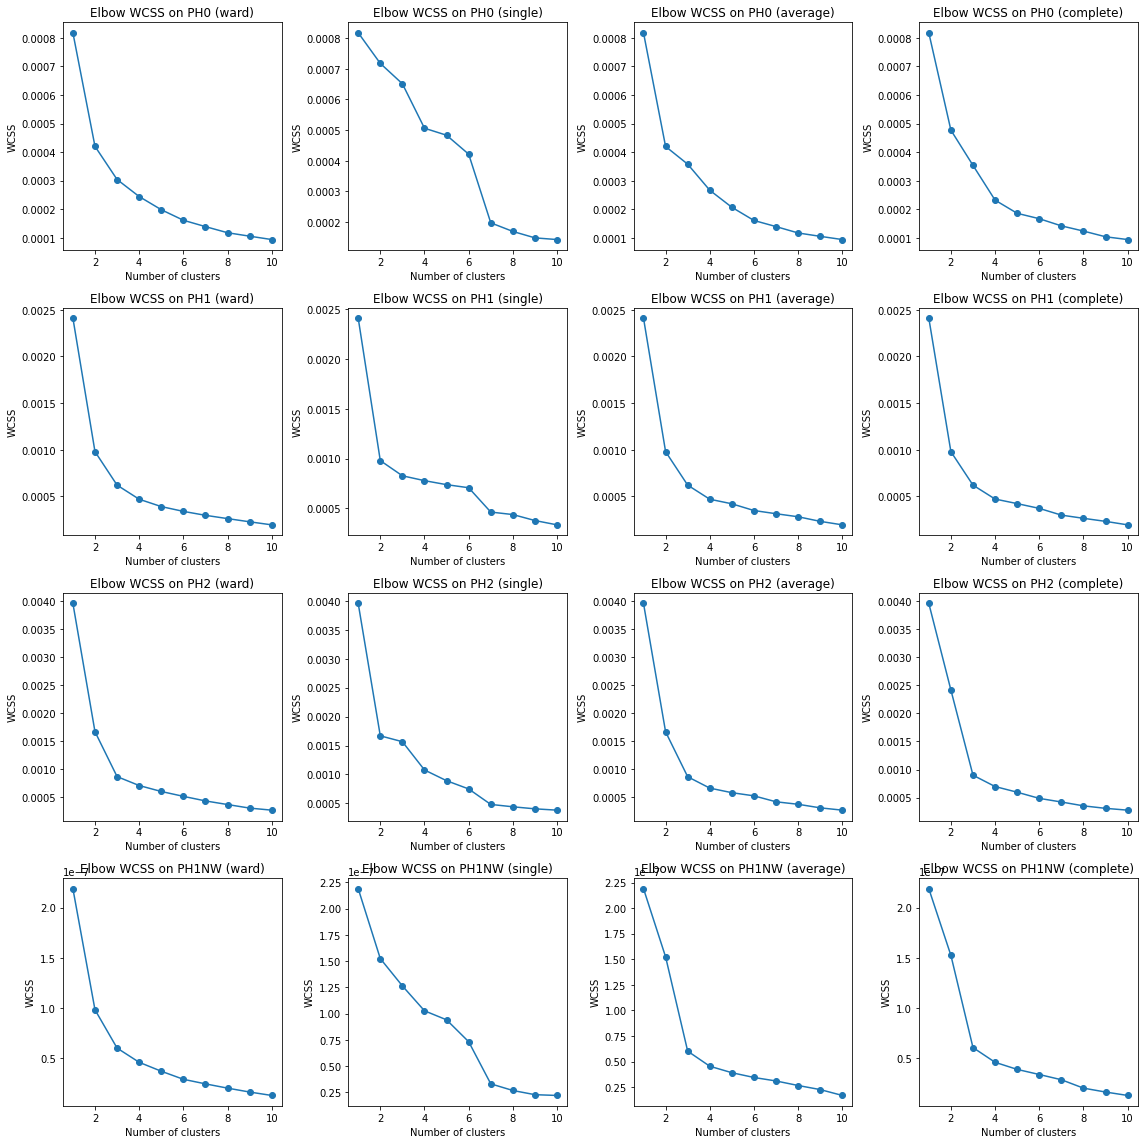

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i, region in enumerate(["PH0", "PH1", "PH2", "PH1NW"]):
    if region == "PH0":
        X = ph0_vec
    elif region == "PH1":
        X = ph1_vec
    elif region == "PH2":
        X = ph2_vec
    elif region == "PH1NW":
        X = ph1nw_vec

    for j, method in enumerate(["ward", "single", "average", "complete"]):
        
        Z = linkage(X, method=method)
        max_k = 10
        wcss_scores = []

        for k in range(1, max_k + 1):
            labels = fcluster(Z, t=k, criterion='maxclust')
            wcss_k = 0
            for cluster_id in np.unique(labels):
                cluster_points = X[labels == cluster_id]
                centroid = cluster_points.mean(axis=0)
                wcss_k += ((cluster_points - centroid) ** 2).sum()
            wcss_scores.append(wcss_k)

        axes[i, j].plot(range(1, max_k + 1), wcss_scores, marker='o')
        axes[i, j].set_title(f"Elbow WCSS on {region} ({method})")
        axes[i, j].set_xlabel("Number of clusters")
        axes[i, j].set_ylabel("WCSS")

plt.tight_layout()
plt.show()

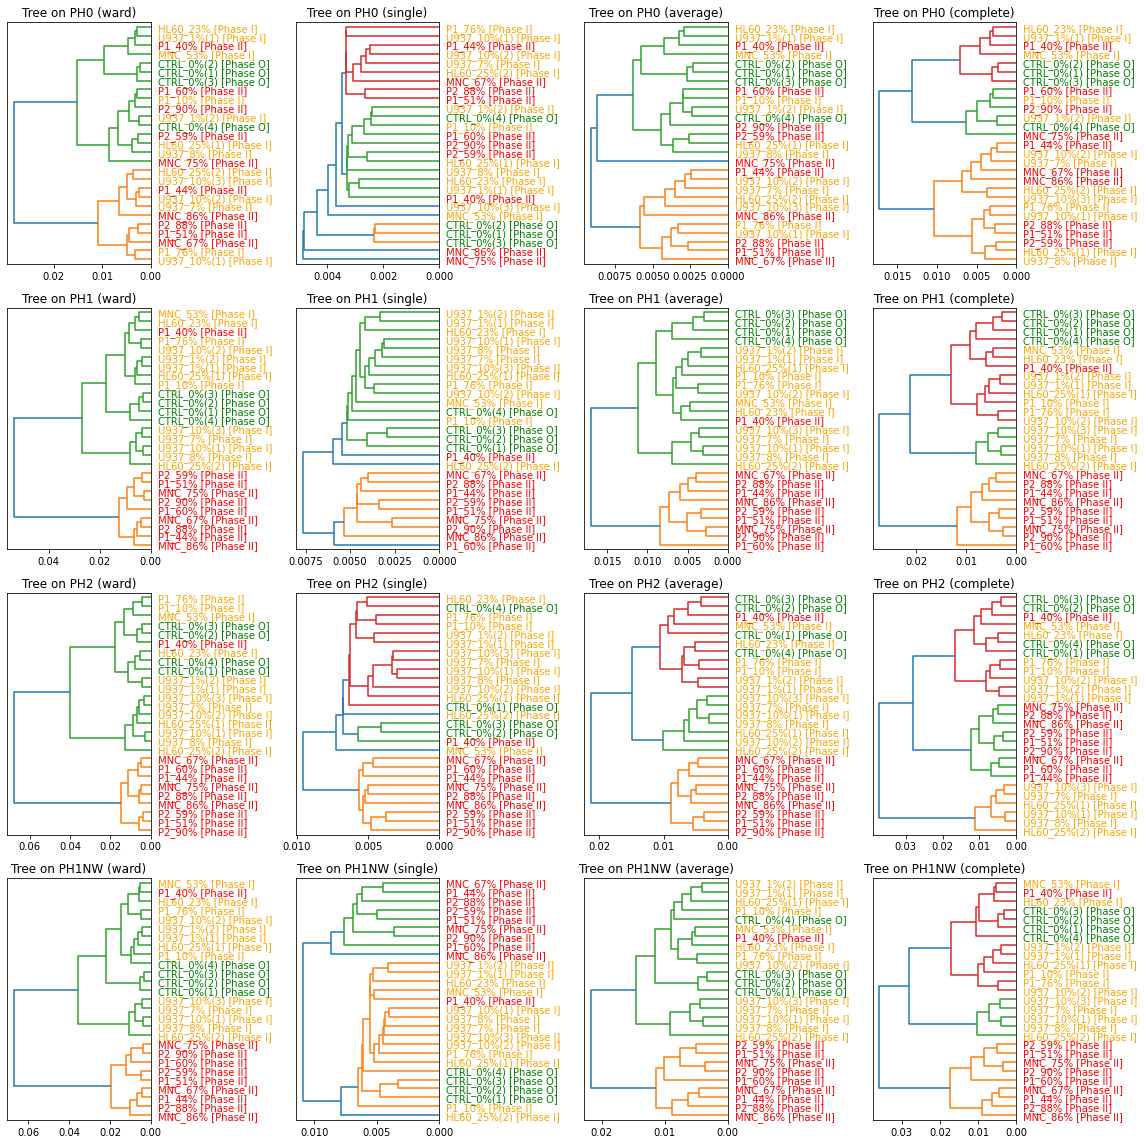

In [38]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i, region in enumerate(["PH0", "PH1", "PH2", "PH1NW"]):
    if region == "PH0":
        X = ph0_vec
    elif region == "PH1":
        X = ph1_vec
    elif region == "PH2":
        X = ph2_vec
    elif region == "PH1NW":
        X = ph1nw_vec

    for j, method in enumerate(["ward", "single", "average", "complete"]):
        
        Z = linkage(X, method=method)
        dendrogram_info = dendrogram(Z, ax = axes[i,j], labels = name_phase,orientation='left')
        ytick_labels = axes[i,j].get_yticklabels()
        leaf_indices = dendrogram_info['leaves']
        for l, leaf_label in enumerate(ytick_labels):
            original_data_index = leaf_indices[l]
            leaf_label.set_color(colour_labels[original_data_index])
            
        axes[i, j].set_title(f"Tree on {region} ({method})")   
plt.tight_layout()
plt.show()

In [4]:
from collections import Counter
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from math import log2
import pandas as pd

def entropy(labels):
    n = len(labels)
    counts = Counter(labels)
    return -sum((count / n) * log2(count / n) for count in counts.values())

def mutual_information(labels1, labels2):
    n = len(labels1)
    counter1 = Counter(labels1)
    counter2 = Counter(labels2)
    joint_counts = Counter(zip(labels1, labels2))

    mi = 0.0
    for (u, v), joint in joint_counts.items():
        p_uv = joint / n
        p_u = counter1[u] / n
        p_v = counter2[v] / n
        mi += p_uv * log2(p_uv / (p_u * p_v))
    return mi

def variation_of_information(labels1, labels2):
    h1 = entropy(labels1)
    h2 = entropy(labels2)
    mi = mutual_information(labels1, labels2)
    return h1 + h2 - 2 * mi

from sklearn.metrics.cluster import contingency_matrix

def split_join_distance(labels1, labels2):
    cm = contingency_matrix(labels1, labels2)
    total_pairs = np.sum(cm)
    sum_max_per_row = np.sum(np.max(cm, axis=1))
    sum_max_per_col = np.sum(np.max(cm, axis=0))
    return 2 * total_pairs - sum_max_per_row - sum_max_per_col

In [22]:
regions = ["PH0", "PH1", "PH2", "PH1NW"]
region_data = {
    "PH0": ph0_vec,
    "PH1": ph1_vec,
    "PH2": ph2_vec,
    "PH1NW": ph1nw_vec
}
y_true = np.array(phases_of_interest)

linkage_methods = ["ward", "average", "complete", "single"]

# Store results
ari_table = pd.DataFrame(index=regions, columns=linkage_methods)
nmi_table = pd.DataFrame(index=regions, columns=linkage_methods)
vi_table = pd.DataFrame(index=regions, columns=linkage_methods)
sj_table = pd.DataFrame(index=regions, columns=linkage_methods)

for region in regions:
    X = region_data[region]

    for method in linkage_methods:
        Z = linkage(X, method=method)

        # Choose number of clusters
        if method == "single":
            k = 7
        else:
            k = 4

        # Get cluster labels
        y_pred = fcluster(Z, t=k, criterion='maxclust')

        # Compute metrics
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)
        vi = variation_of_information(y_true, y_pred)
        sj = split_join_distance(y_true, y_pred)

        # Store in tables
        ari_table.loc[region, method] = round(ari, 3)
        nmi_table.loc[region, method] = round(nmi, 3)
        vi_table.loc[region, method] = round(vi, 3)
        sj_table.loc[region, method] = round(sj, 3)

# Display tables
print("Adjusted Rand Index (ARI):\n", ari_table, "\n")
print("Normalized Mutual Information (NMI):\n", nmi_table, "\n")
print("Variation of Information (VI):\n", vi_table/(np.log(27)), "\n")
print("Split/Join Distance:\n", sj_table/(27*26/2), "\n")


Adjusted Rand Index (ARI):
         ward average complete single
PH0   -0.015   0.023   -0.009  0.071
PH1    0.626   0.626    0.502  0.673
PH2    0.463   0.529    0.502  0.498
PH1NW  0.069   0.069    0.069  0.052 

Normalized Mutual Information (NMI):
         ward average complete single
PH0    0.131   0.157    0.137  0.325
PH1    0.761   0.761    0.638  0.716
PH2    0.552   0.614    0.638  0.628
PH1NW  0.227   0.227    0.227  0.248 

Variation of Information (VI):
            ward   average  complete    single
PH0    0.900227  0.811933  0.901744  0.729405
PH1    0.243944  0.243944  0.374412   0.30311
PH2    0.463615  0.399292  0.374412  0.430847
PH1NW  0.662958  0.662958  0.662958  0.730012 

Split/Join Distance:
            ward   average  complete    single
PH0    0.082621  0.074074   0.08547  0.065527
PH1    0.019943  0.019943  0.031339  0.017094
PH2    0.039886  0.031339  0.031339  0.034188
PH1NW  0.054131  0.054131  0.054131  0.054131 



## Bootstrap Consensus Clustering with hierachical clustering



For B bootstrap samples:

- Sample data with replacement.

- Compute hierarchical clustering.

- Cut at fixed number of clusters kk.

- Store cluster labels.

Build co-association matrix: for each pair, fraction of clusterings where they co-occur in same cluster.

Cluster the co-association matrix (e.g., with average linkage) to get consensus labels.

In [5]:
def bootstrap_consensus_hierarchical(X, B=100, k=4, method='ward', random_state=None):
    np.random.seed(random_state)
    n = X.shape[0]
    coassoc = np.zeros((n, n))
    
    for b in range(B):
        # Bootstrap sample indices
        sample_idx = np.random.choice(n, size=n, replace=True)
        X_sample = X[sample_idx]
        
        # Linkage on bootstrap sample
        Z = linkage(X_sample, method=method)
        
        # Cut dendrogram to get k clusters
        labels_sample = fcluster(Z, t=k, criterion='maxclust')
        
        # Map labels back to original indices
        # Because of bootstrap, some points repeated; build co-assoc for original data
        # For each pair of points in original data:
        for i in range(n):
            for j in range(i + 1, n):
                # Find all occurrences of i and j in bootstrap sample
                i_locs = np.where(sample_idx == i)[0]
                j_locs = np.where(sample_idx == j)[0]
                # If either i or j not in sample, skip
                if len(i_locs) == 0 or len(j_locs) == 0:
                    continue
                # Check if they clustered together in any occurrence
                co_cluster = False
                for il in i_locs:
                    for jl in j_locs:
                        if labels_sample[il] == labels_sample[jl]:
                            co_cluster = True
                            break
                    if co_cluster:
                        break
                if co_cluster:
                    coassoc[i, j] += 1
                    coassoc[j, i] += 1
    
    # Normalize co-association matrix
    coassoc /= B
    
    # Cluster co-association matrix (distance = 1 - coassoc)
    agg = AgglomerativeClustering(n_clusters=k, affinity='precomputed', linkage='average')
    consensus_labels = agg.fit_predict(1 - coassoc)
    
    return consensus_labels, coassoc



### PH1

In [47]:
consensus_labels, coassoc = bootstrap_consensus_hierarchical(ph1_vec, B=100, k=4)

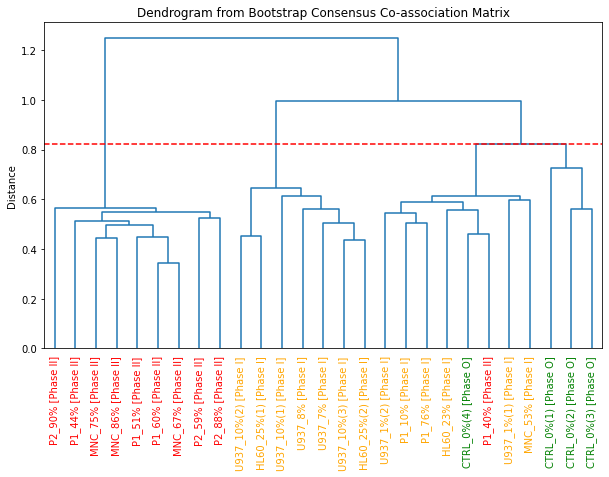

In [59]:
# Perform linkage on (1 - coassoc) since it's a similarity matrix
Z = linkage(1 - coassoc, method='average')

plt.figure(figsize=(10, 6))
dendrogram_info = dendrogram(Z, labels=name_phase, leaf_rotation=90, color_threshold=0)
ax = plt.gca()
plt.axhline(y=Z[-4 + 1, 2], color='red', linestyle='--', label='Cut for 4 clusters')  # 4-1 index in Z
xtick_labels = ax.get_xticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(xtick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])

plt.title("Dendrogram from Bootstrap Consensus Co-association Matrix")
plt.ylabel("Distance")
plt.show()

### For PH2

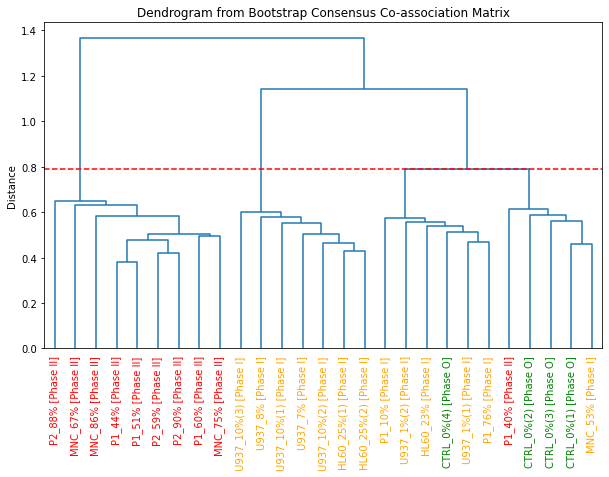

In [11]:
consensus_labels, coassoc = bootstrap_consensus_hierarchical(ph2_vec, B=100, k=4)
Z = linkage(1 - coassoc, method='average')

plt.figure(figsize=(10, 6))
dendrogram_info = dendrogram(Z, labels=name_phase, leaf_rotation=90, color_threshold=0)
ax = plt.gca()
plt.axhline(y=Z[-4 + 1, 2], color='red', linestyle='--', label='Cut for 4 clusters')  # 4-1 index in Z
xtick_labels = ax.get_xticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(xtick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])

plt.title("Dendrogram from Bootstrap Consensus Co-association Matrix")
plt.ylabel("Distance")
plt.show()


## Consensus from different linkage methods (no bootstrapping)

Run hierarchical clustering with different linkage methods (ward, average, complete, single).

Collect cluster labels (cut at fixed kk).

Build co-association matrix from these labels similarly.

Cluster the co-association matrix.

In [7]:
def linkage_consensus(X, k=4, methods=['ward','average','complete','single']):
    n = X.shape[0]
    coassoc = np.zeros((n, n))
    B = len(methods)
    
    for method in methods:
        Z = linkage(X, method=method)
        labels = fcluster(Z, t=k, criterion='maxclust')
        
        for i in range(n):
            for j in range(i+1, n):
                if labels[i] == labels[j]:
                    coassoc[i, j] += 1
                    coassoc[j, i] += 1
    
    coassoc /= B
    
    agg = AgglomerativeClustering(n_clusters=k, affinity='precomputed', linkage='average')
    consensus_labels = agg.fit_predict(1 - coassoc)
    return consensus_labels, coassoc


### PH1

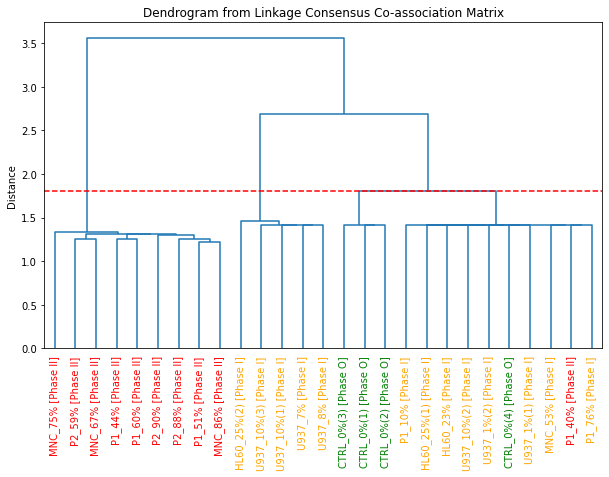

In [62]:
consensus_labels, coassoc = linkage_consensus(X, k=4)
# Perform linkage on (1 - coassoc) since it's a similarity matrix
Z = linkage(1 - coassoc, method='average')

plt.figure(figsize=(10, 6))
dendrogram_info = dendrogram(Z, labels=name_phase, leaf_rotation=90, color_threshold=0)
ax = plt.gca()
plt.axhline(y=Z[-4 + 1, 2], color='red', linestyle='--', label='Cut for 4 clusters')  # 4-1 index in Z
xtick_labels = ax.get_xticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(xtick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])

plt.title("Dendrogram from Linkage Consensus Co-association Matrix")
plt.ylabel("Distance")
plt.show()

### For PH2

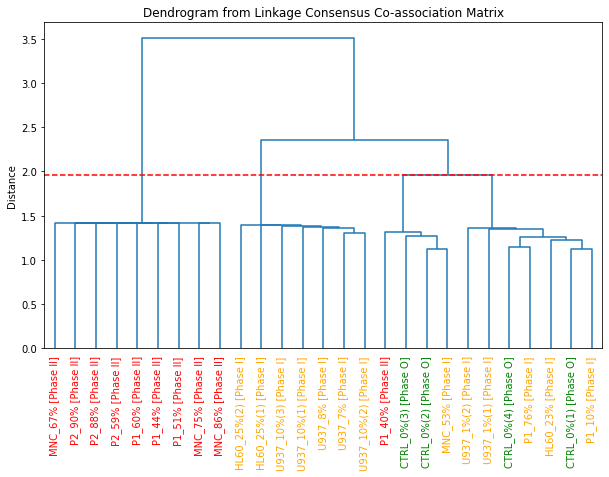

In [9]:
consensus_labels, coassoc = linkage_consensus(ph2_vec, k=4)
# Perform linkage on (1 - coassoc) since it's a similarity matrix
Z = linkage(1 - coassoc, method='average')

plt.figure(figsize=(10, 6))
dendrogram_info = dendrogram(Z, labels=name_phase, leaf_rotation=90, color_threshold=0)
ax = plt.gca()
plt.axhline(y=Z[-4 + 1, 2], color='red', linestyle='--', label='Cut for 4 clusters')  # 4-1 index in Z
xtick_labels = ax.get_xticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(xtick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])

plt.title("Dendrogram from Linkage Consensus Co-association Matrix")
plt.ylabel("Distance")
plt.show()

### Some example plots

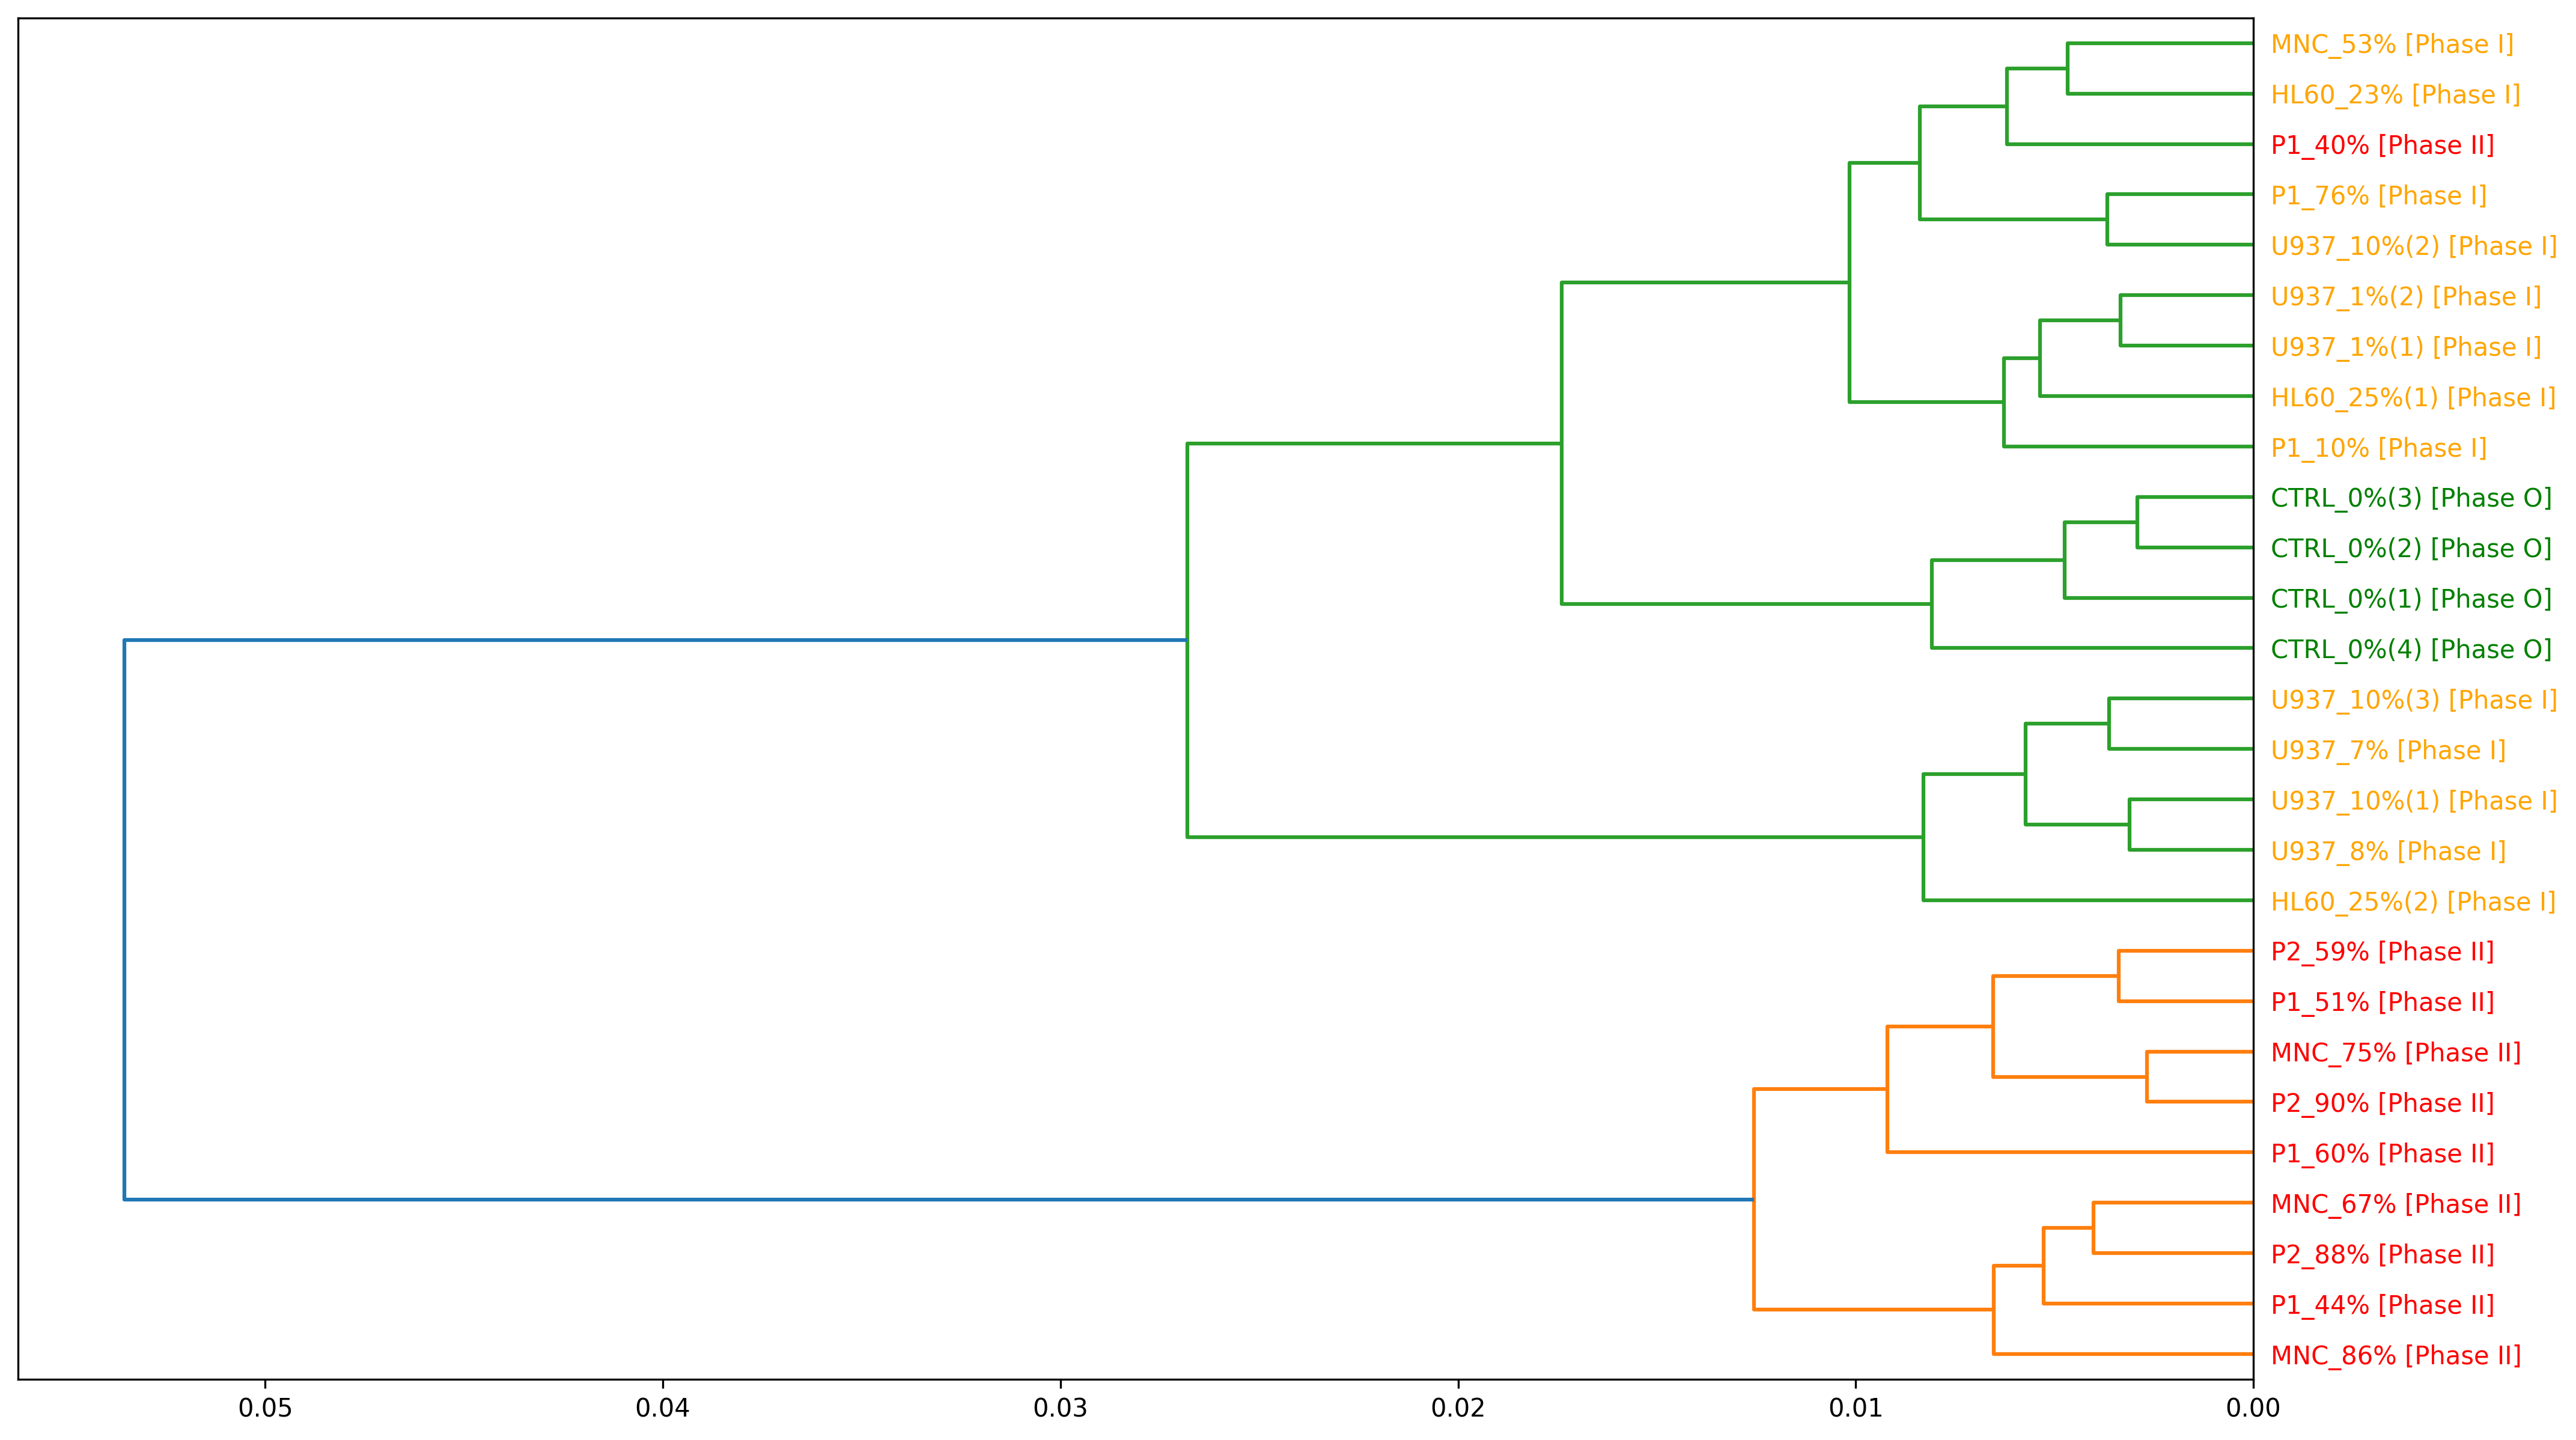

In [33]:
plt.figure(figsize=(16,10),dpi=300)
Z = linkage(ph1_vec, method='ward')
dendrogram_info = dendrogram(Z, labels = name_phase,orientation='left')
ax = plt.gca()
ytick_labels = ax.get_yticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(ytick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])
plt.savefig("ph1_tree.png")
plt.show()

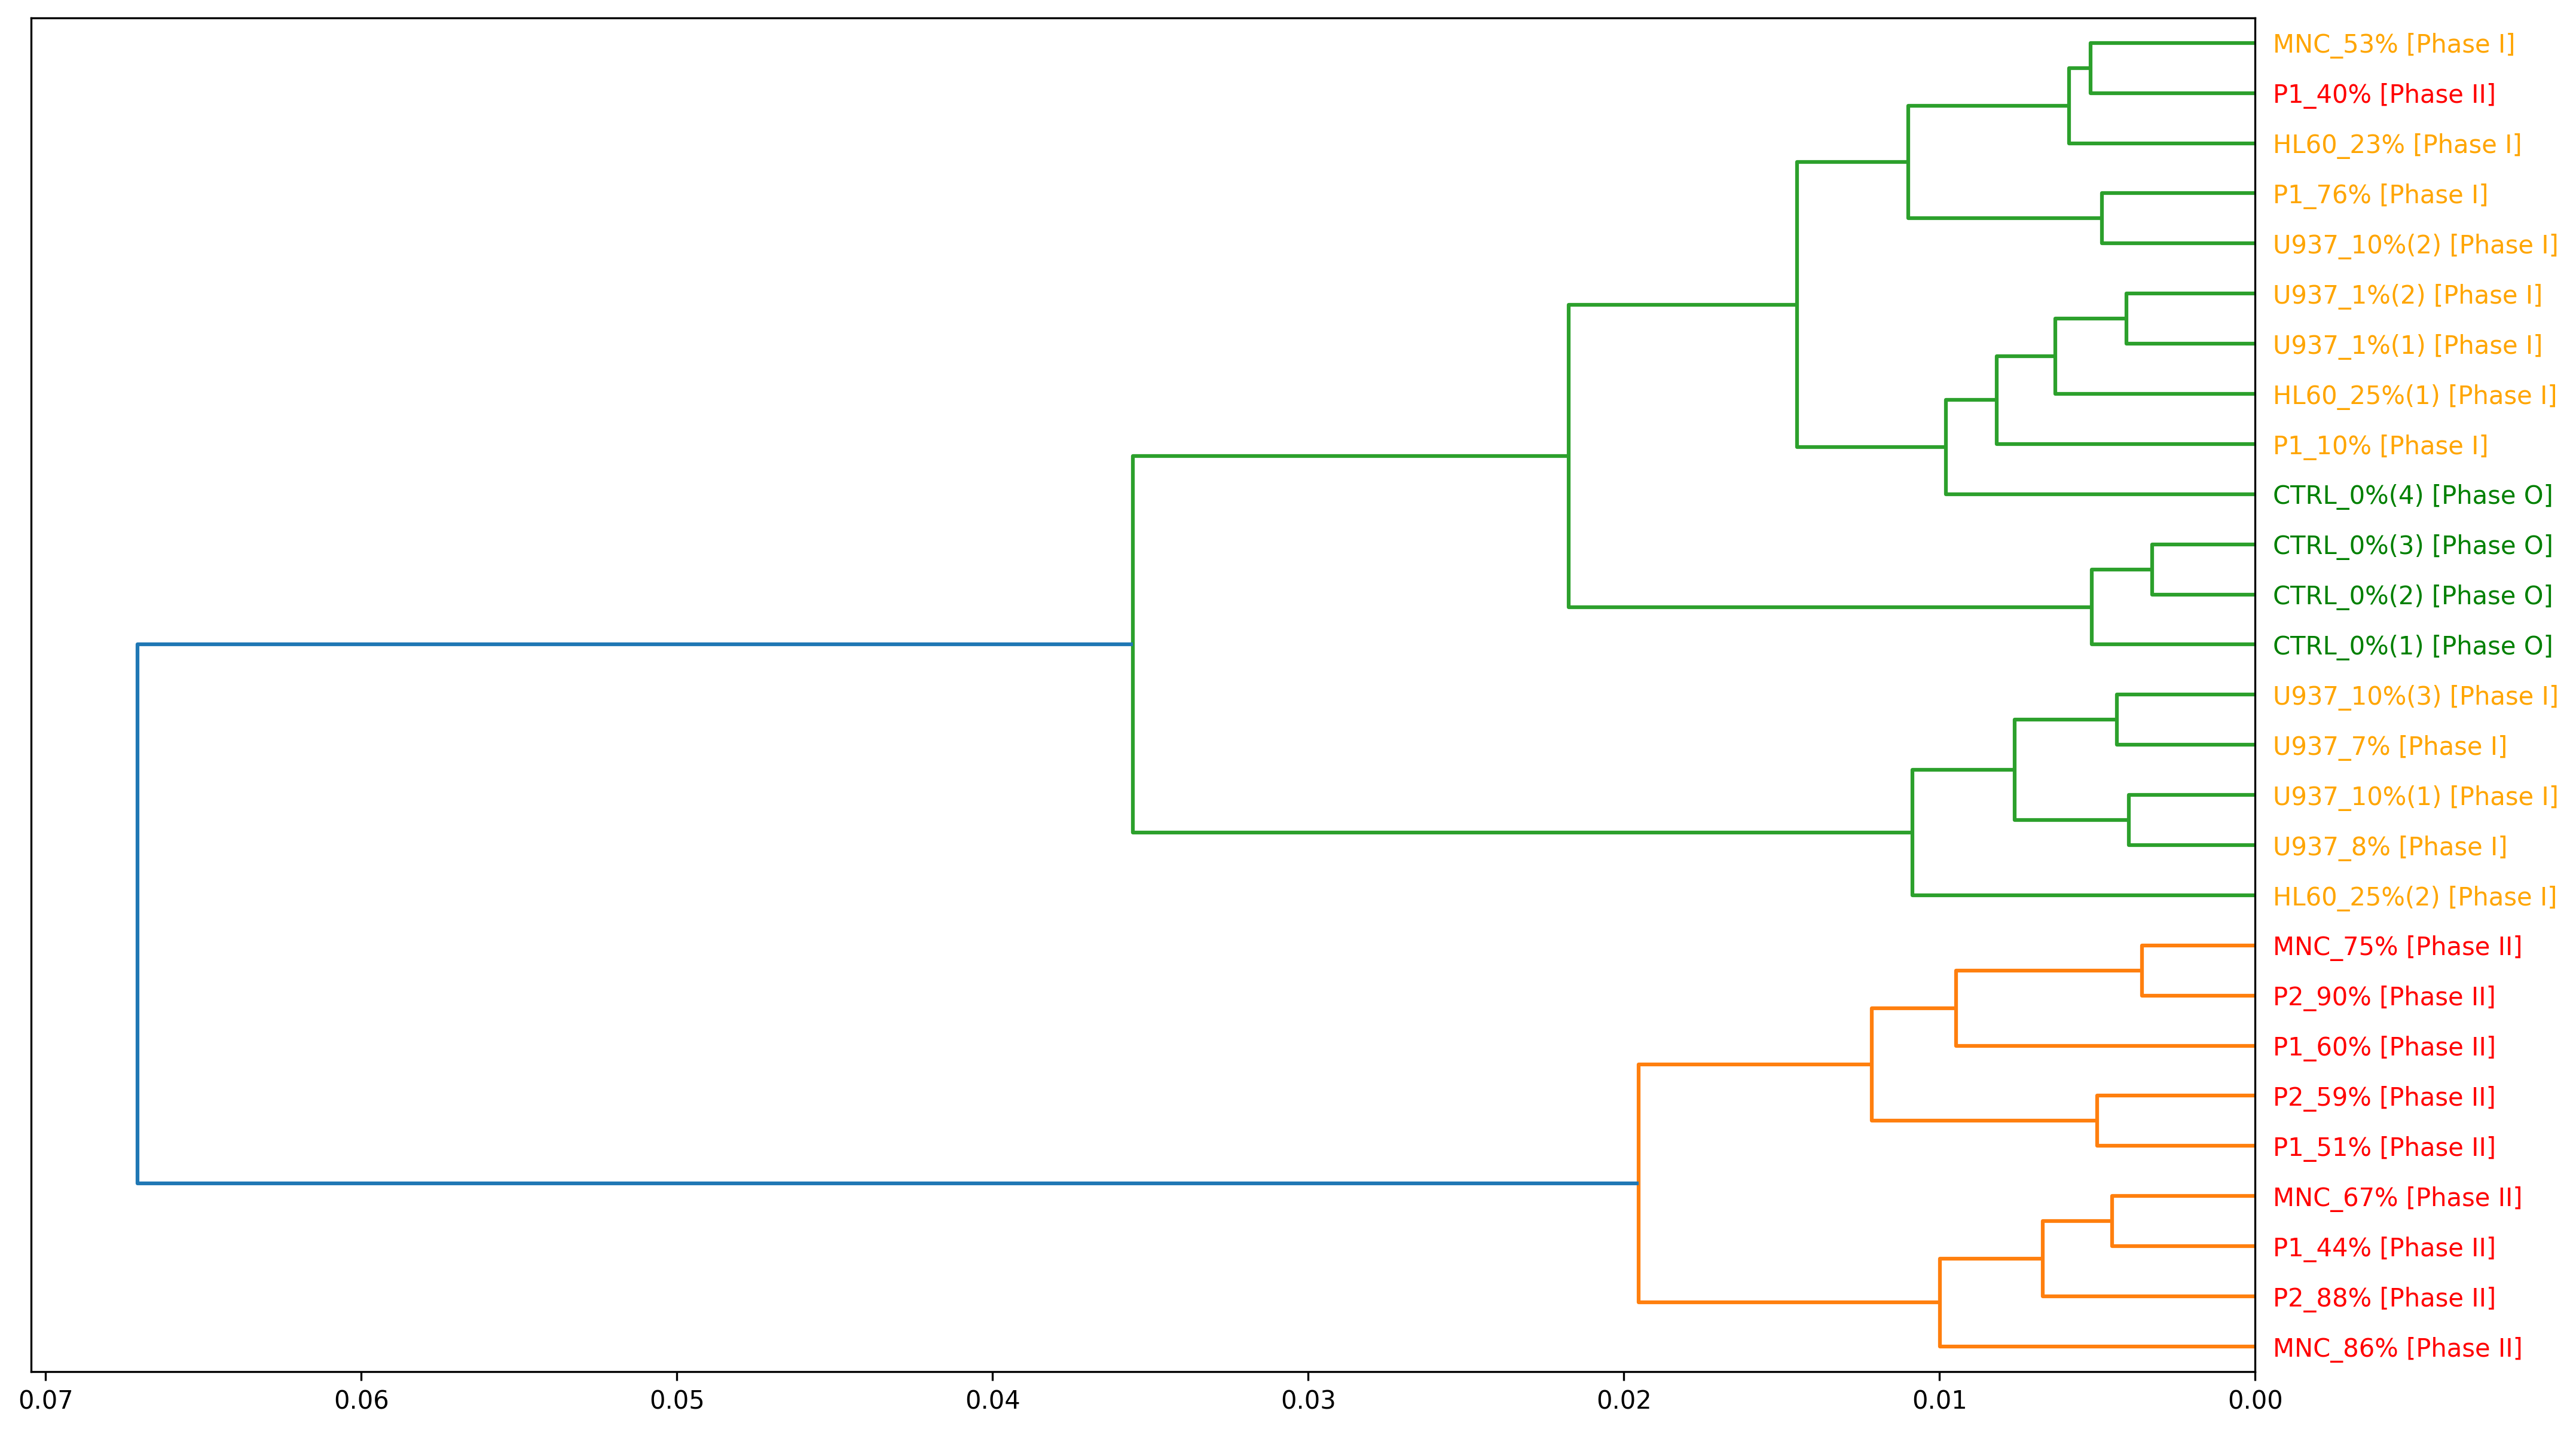

In [32]:
plt.figure(figsize=(16,10),dpi=300)
Z = linkage(ph1nw_vec, method='ward')
dendrogram_info = dendrogram(Z, labels = name_phase,orientation='left')
ax = plt.gca()
ytick_labels = ax.get_yticklabels()
leaf_indices = dendrogram_info['leaves']
for i, leaf_label in enumerate(ytick_labels):
    original_data_index = leaf_indices[i]
    leaf_label.set_color(colour_labels[original_data_index])
plt.savefig("ph1nw_tree.png")
plt.show()